# Tutorial 3 — Packet loss and failure counts

## 1. Problem / context

A link drops packets independently with probability \(p=0.04\). In a burst of \(n=50\) packets, how many losses should we expect, and what is \(P(X\ge 5)\)? Separately, rare hardware faults on a rack are modelled as a Poisson count with mean \(\lambda=1.6\) faults per week.

## 2. Core theory

A **random variable** \(X\) assigns a number to each outcome. Before we observe data, we write \(X\); after we see a number we write \(x\).

For a discrete variable the **PMF** is \(p_X(k)=P(X=k)\). The **CDF** is \(F_X(k)=P(X\le k)\).

\[
E[X]=\sum_k k\,p_X(k),
\qquad
\operatorname{Var}(X)=E[X^2]-(E[X])^2.
\]

**Bernoulli**(\(p\)): one trial, success probability \(p\).

**Binomial**(\(n,p\)): \(n\) independent Bernoulli trials. The binomial coefficient \(\binom{n}{k}\) counts the ways to place \(k\) successes among \(n\) trials:

\[
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}.
\]

**Poisson**(\(\lambda\)): a counting model for rare events in a fixed interval, with \(E[X]=\operatorname{Var}(X)=\lambda\).

## 3. From mathematics to Python

| Model | SciPy object | Probability \(P(X\le k)\) |
| --- | --- | --- |
| Binomial | `binom(n=n, p=p)` | `binom.cdf(k, n, p)` |
| Poisson | `poisson(mu=lam)` | `poisson.cdf(k, mu=lam)` |

Use `sf(k-1)` or `1 - cdf(k-1)` for \(P(X\ge k)\). SciPy's `sf` is the survival function \(P(X>k)\) for discrete distributions as implemented — check the docstring and prefer `1 - cdf(k-1)` when you want \(P(X\ge k)\).

## 4. Python implementation


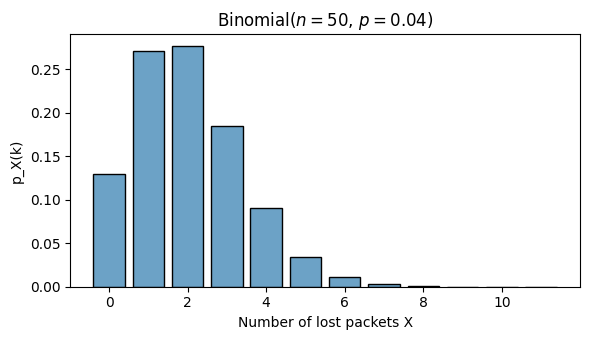

E[X] = 2.0  Var(X) = 1.92
P(X >= 5) = 0.048971471884512785


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import binom, poisson

n, p = 50, 0.04
k = np.arange(0, 12)
pmf = binom.pmf(k, n, p)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(k, pmf, color="#6CA2C6", edgecolor="black")
ax.set_xlabel("Number of lost packets X")
ax.set_ylabel("p_X(k)")
ax.set_title(r"Binomial($n=50$, $p=0.04$)")
plt.tight_layout()
plt.show()

print("E[X] =", binom.mean(n, p), " Var(X) =", binom.var(n, p))
print("P(X >= 5) =", 1 - binom.cdf(4, n, p))


Empirical rate from the course file:


In [2]:
candidates = [Path("data"), Path("../data")]
DATA = next(p for p in candidates if p.exists())
loss = pd.read_csv(DATA / "packet_loss.csv")
p_hat = loss["packet_lost"].mean()
print("Observed loss rate:", p_hat)
print("In 50 trials, estimated mean losses:", 50 * p_hat)


Observed loss rate: 0.04
In 50 trials, estimated mean losses: 2.0


Poisson weekly faults:


In [3]:
lam = 1.6
print("P(no fault in a week) =", poisson.pmf(0, mu=lam))
print("P(at least 3 faults) =", 1 - poisson.cdf(2, mu=lam))


P(no fault in a week) = 0.20189651799465538
P(at least 3 faults) = 0.21664151018073696


## 5. Interpretation

If losses are independent with \(p=0.04\), five or more losses in 50 packets is the right tail of a binomial, not a “typical” week. The Poisson model is a different story: it describes **counts of rare events in time**, not the number of successes in a fixed number of Bernoulli trials. Use binomial when \(n\) and \(p\) are defined by a fixed number of independent trials; use Poisson when you have a rate in a window of time or space.

## 6. Common mistakes / things to notice

- Using Poisson for a fixed number of packet trials (use binomial).
- Writing \(X\sim N(\mu,\sigma)\) later in the course — wait for Session 04, and then use variance \(\sigma^2\).
- Forgetting that \(\binom{n}{k}\) is introduced here because the binomial needs it, not because STA1 is a combinatorics course.

## 7. Short worked example

A plant inspects 20 boards. Each is independently non-conforming with probability 0.03. Find \(P(X=0)\) and \(P(X\ge 2)\).


In [4]:
print(binom.pmf(0, 20, 0.03))
print(1 - binom.cdf(1, 20, 0.03))


0.5437943429267471
0.11983802227320284


**Conclusion in one sentence:** Packet losses in a fixed burst are a binomial count; five or more losses in 50 packets has probability `1 - binom.cdf(4, 50, 0.04)`, which is small but not negligible for reliability reporting.
